# Computer Vision Using Deep Learning - Practical 5

# Frequency Domain Filtering in Images

- Ideal LPF & HPF
- Butterworth LPF & HPF
- Gaussian LPF & HPF

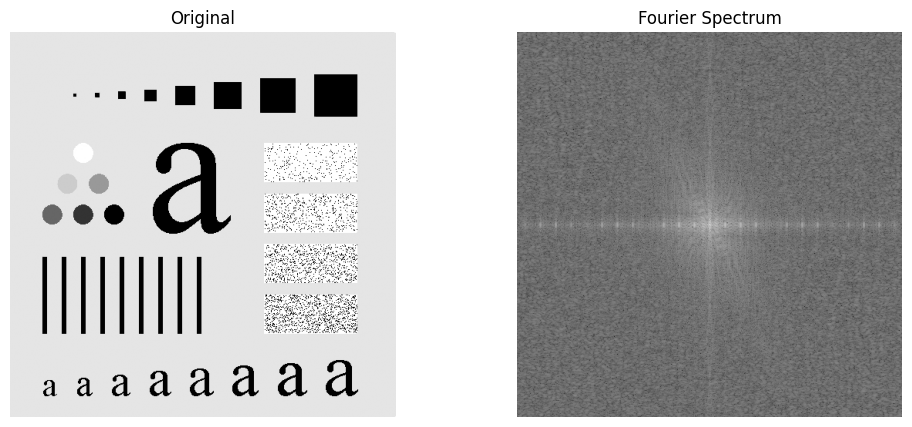

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('abcl.jpg', cv2.IMREAD_GRAYSCALE)
M, N = img.shape

F = np.fft.fft2(img)
Fshift = np.fft.fftshift(F)
magnitude_spectrum = np.log(1 + np.abs(Fshift))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1), plt.imshow(img, cmap='gray'), plt.title("Original"), plt.axis("off")
plt.subplot(1,2,2), plt.imshow(magnitude_spectrum, cmap='gray'), plt.title("Fourier Spectrum"), plt.axis("off")
plt.show()

u = np.arange(M)
v = np.arange(N)
V, U = np.meshgrid(v, u)
D = np.sqrt((U - M/2)**2 + (V - N/2)**2)


## Ideal Low-Pass Filter (ILPF)


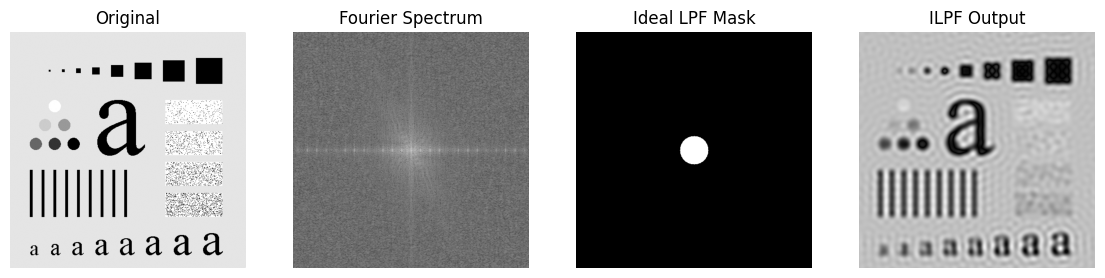

In [2]:
D0 = 30
H = (D <= D0).astype(np.float32)
G = Fshift * H
g = np.abs(np.fft.ifft2(np.fft.ifftshift(G)))

plt.figure(figsize=(14,5))
plt.subplot(1,4,1), plt.imshow(img, cmap='gray'), plt.title("Original"), plt.axis("off")
plt.subplot(1,4,2), plt.imshow(magnitude_spectrum, cmap='gray'), plt.title("Fourier Spectrum"), plt.axis("off")
plt.subplot(1,4,3), plt.imshow(H, cmap='gray'), plt.title("Ideal LPF Mask"), plt.axis("off")
plt.subplot(1,4,4), plt.imshow(g, cmap='gray'), plt.title("ILPF Output"), plt.axis("off")
plt.show()


## Butterworth Low-Pass Filter (BLPF)


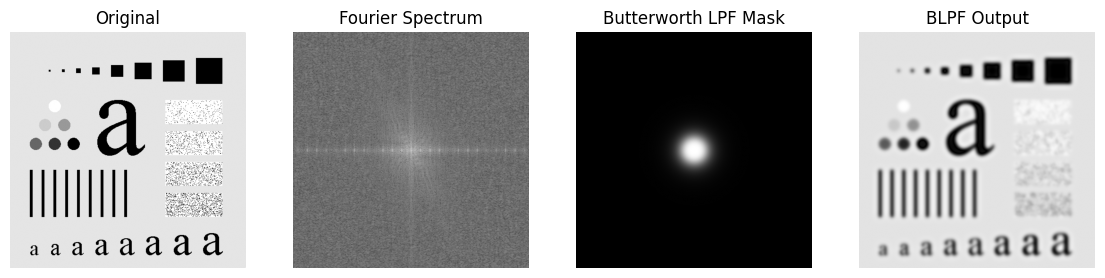

In [3]:
D0 = 30
n = 2
H = 1 / (1 + (D/D0)**(2*n))
G = Fshift * H
g = np.abs(np.fft.ifft2(np.fft.ifftshift(G)))

plt.figure(figsize=(14,5))
plt.subplot(1,4,1), plt.imshow(img, cmap='gray'), plt.title("Original"), plt.axis("off")
plt.subplot(1,4,2), plt.imshow(magnitude_spectrum, cmap='gray'), plt.title("Fourier Spectrum"), plt.axis("off")
plt.subplot(1,4,3), plt.imshow(H, cmap='gray'), plt.title("Butterworth LPF Mask"), plt.axis("off")
plt.subplot(1,4,4), plt.imshow(g, cmap='gray'), plt.title("BLPF Output"), plt.axis("off")
plt.show()


## Gaussian Low-Pass Filter (GLPF)


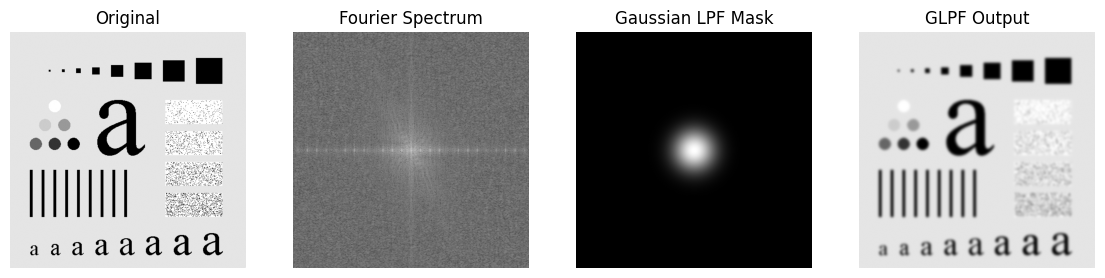

In [4]:
D0 = 30
H = np.exp(-(D**2) / (2*(D0**2)))
G = Fshift * H
g = np.abs(np.fft.ifft2(np.fft.ifftshift(G)))

plt.figure(figsize=(14,5))
plt.subplot(1,4,1), plt.imshow(img, cmap='gray'), plt.title("Original"), plt.axis("off")
plt.subplot(1,4,2), plt.imshow(magnitude_spectrum, cmap='gray'), plt.title("Fourier Spectrum"), plt.axis("off")
plt.subplot(1,4,3), plt.imshow(H, cmap='gray'), plt.title("Gaussian LPF Mask"), plt.axis("off")
plt.subplot(1,4,4), plt.imshow(g, cmap='gray'), plt.title("GLPF Output"), plt.axis("off")
plt.show()


## Ideal High-Pass Filter (IHPF)


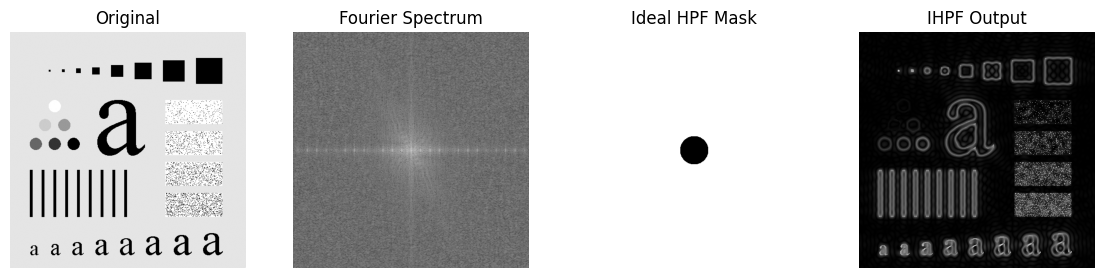

In [5]:
D0 = 30
H = (D >= D0).astype(np.float32)
G = Fshift * H
g = np.abs(np.fft.ifft2(np.fft.ifftshift(G)))

plt.figure(figsize=(14,5))
plt.subplot(1,4,1), plt.imshow(img, cmap='gray'), plt.title("Original"), plt.axis("off")
plt.subplot(1,4,2), plt.imshow(magnitude_spectrum, cmap='gray'), plt.title("Fourier Spectrum"), plt.axis("off")
plt.subplot(1,4,3), plt.imshow(H, cmap='gray'), plt.title("Ideal HPF Mask"), plt.axis("off")
plt.subplot(1,4,4), plt.imshow(g, cmap='gray'), plt.title("IHPF Output"), plt.axis("off")
plt.show()


## Butterworth High-Pass Filter (BHPF)


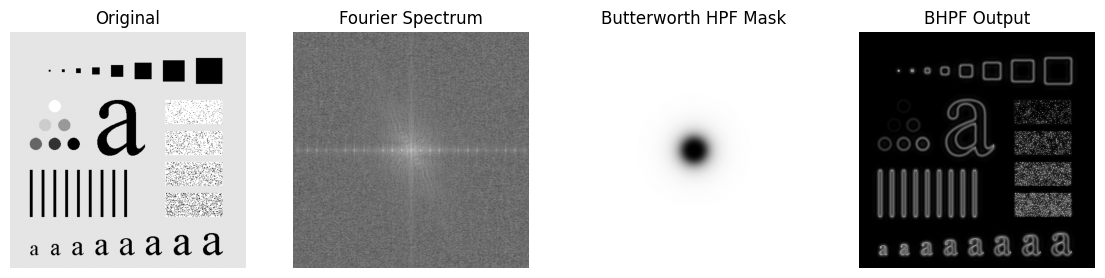

In [6]:
D0 = 30
n = 2
H = 1 - (1 / (1 + (D/D0)**(2*n)))
G = Fshift * H
g = np.abs(np.fft.ifft2(np.fft.ifftshift(G)))

plt.figure(figsize=(14,5))
plt.subplot(1,4,1), plt.imshow(img, cmap='gray'), plt.title("Original"), plt.axis("off")
plt.subplot(1,4,2), plt.imshow(magnitude_spectrum, cmap='gray'), plt.title("Fourier Spectrum"), plt.axis("off")
plt.subplot(1,4,3), plt.imshow(H, cmap='gray'), plt.title("Butterworth HPF Mask"), plt.axis("off")
plt.subplot(1,4,4), plt.imshow(g, cmap='gray'), plt.title("BHPF Output"), plt.axis("off")
plt.show()


## Gaussian High-Pass Filter (GHPF)


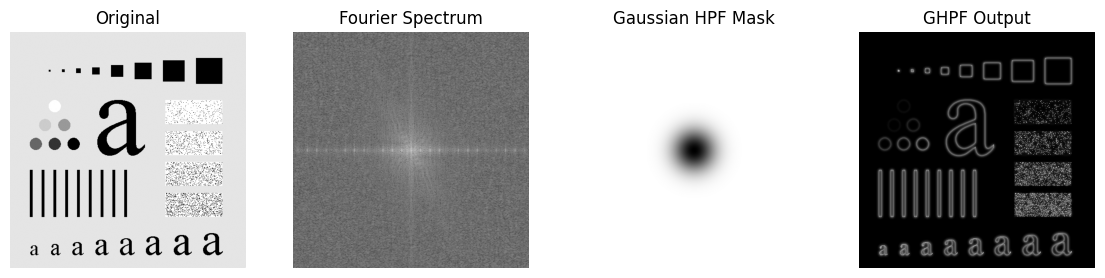

In [7]:
D0 = 30
H = 1 - np.exp(-(D**2) / (2*(D0**2)))
G = Fshift * H
g = np.abs(np.fft.ifft2(np.fft.ifftshift(G)))

plt.figure(figsize=(14,5))
plt.subplot(1,4,1), plt.imshow(img, cmap='gray'), plt.title("Original"), plt.axis("off")
plt.subplot(1,4,2), plt.imshow(magnitude_spectrum, cmap='gray'), plt.title("Fourier Spectrum"), plt.axis("off")
plt.subplot(1,4,3), plt.imshow(H, cmap='gray'), plt.title("Gaussian HPF Mask"), plt.axis("off")
plt.subplot(1,4,4), plt.imshow(g, cmap='gray'), plt.title("GHPF Output"), plt.axis("off")
plt.show()
